Task 1: Develop predictive regression models using Linear Regression techniques for continuous-valued data analysis
Suggested Dataset: Boston Housing Dataset (Fetched via public repository URL)*


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
# Load the Boston Housing dataset from a reliable public CSV repository
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
boston_df = pd.read_csv(boston_url)

# Define features and continuous target column (medv: median home value)
features = [col for col in boston_df.columns if col != 'medv']
X = boston_df[features]
y = boston_df['medv']

# Split dataset into training and test validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Dataset Dimensions (rows, cols):", boston_df.shape)
print("Missing values per column:\n", boston_df.isnull().sum())
print("\nFirst 3 rows of target data:")
print(y_train.head(3))


Dataset Dimensions (rows, cols): (506, 14)
Missing values per column:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

First 3 rows of target data:
477    12.0
15     19.9
332    19.4
Name: medv, dtype: float64


In [2]:
from sklearn.preprocessing import StandardScaler

# Standardize feature metrics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardized training features mean (approx 0):", round(X_train_scaled.mean(), 4))
print("Standardized training features std dev (approx 1):", round(X_train_scaled.std(), 4))


Standardized training features mean (approx 0): -0.0
Standardized training features std dev (approx 1): 1.0


In [3]:
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train (fit) the model
lr_model.fit(X_train, y_train)
# Predict on the test set
y_pred = lr_model.predict(X_test)

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on the test dataset
y_pred = lr_model.predict(X_test)

# Calculate regression performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display performance metrics
print("Linear Regression Performance Metrics")
print("-------------------------------------")
print(f"Mean Absolute Error (MAE)      : {mae:.4f}")
print(f"Mean Squared Error (MSE)       : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R² Score                       : {r2:.4f}")

Linear Regression Performance Metrics
-------------------------------------
Mean Absolute Error (MAE)      : 3.1891
Mean Squared Error (MSE)       : 24.2911
Root Mean Squared Error (RMSE) : 4.9286
R² Score                       : 0.6688


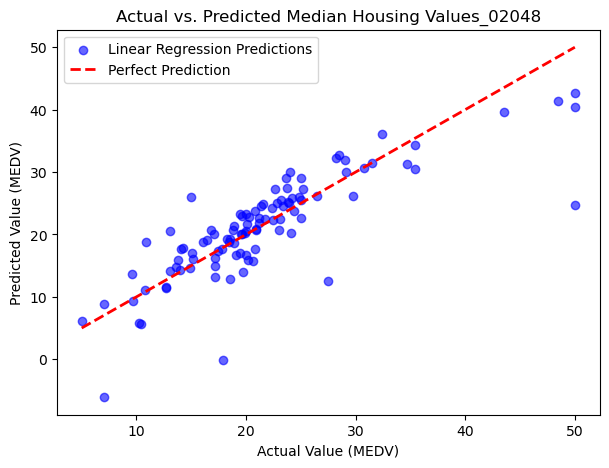

In [5]:
import matplotlib.pyplot as plt

# Generate predictions
lr_predictions = lr_model.predict(X_test)

# Plot Actual vs Predicted
plt.figure(figsize=(7,5))

plt.scatter(y_test, lr_predictions,
            color='blue',
            alpha=0.6,
            label='Linear Regression Predictions')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--',
         lw=2,
         label='Perfect Prediction')

plt.title("Actual vs. Predicted Median Housing Values_02048")
plt.xlabel("Actual Value (MEDV)")
plt.ylabel("Predicted Value (MEDV)")
plt.legend()

plt.show()

Task 2: Implement Support Vector Regression and Decision Tree Regression models for comparative performance analysis (Suggested Dataset: Boston Housing Dataset).

In [6]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and Train SVR Model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)

# Predict
svr_predictions = svr_model.predict(X_test_scaled)

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate performance metrics
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)

# Display results
print("Support Vector Regression Performance Metrics")
print("---------------------------------------------")
print(f"Mean Absolute Error (MAE)      : {svr_mae:.4f}")
print(f"Mean Squared Error (MSE)       : {svr_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {svr_rmse:.4f}")
print(f"R² Score                       : {svr_r2:.4f}")

Support Vector Regression Performance Metrics
---------------------------------------------
Mean Absolute Error (MAE)      : 2.7317
Mean Squared Error (MSE)       : 25.6685
Root Mean Squared Error (RMSE) : 5.0664
R² Score                       : 0.6500


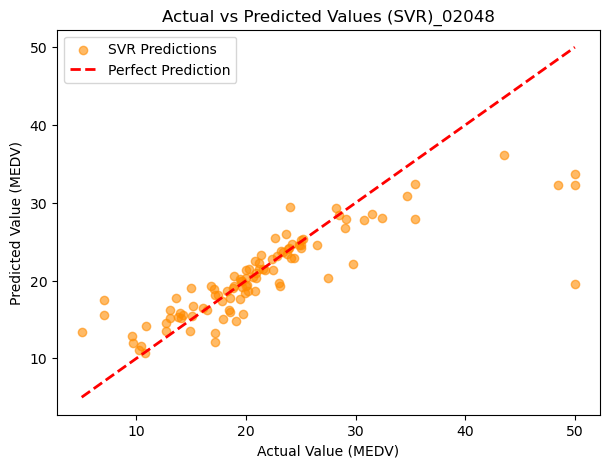

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, svr_predictions,
            color='darkorange',
            alpha=0.6,
            label='SVR Predictions')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--',
         lw=2,
         label='Perfect Prediction')

plt.title("Actual vs Predicted Values (SVR)_02048")
plt.xlabel("Actual Value (MEDV)")
plt.ylabel("Predicted Value (MEDV)")
plt.legend()

plt.show()

In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import numpy as np
# import matplotlib.pyplot as plt

# Create the Decision Tree Regression model
dt_model = DecisionTreeRegressor(random_state=42)

# Train (fit) the model
dt_model.fit(X_train, y_train)

# Predict
dt_predictions = dt_model.predict(X_test)

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate performance metrics
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

# Display results
print("Decision Tree Regression Performance Metrics")
print("--------------------------------------------")
print(f"Mean Absolute Error (MAE)      : {dt_mae:.4f}")
print(f"Mean Squared Error (MSE)       : {dt_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {dt_rmse:.4f}")
print(f"R² Score                       : {dt_r2:.4f}")

Decision Tree Regression Performance Metrics
--------------------------------------------
Mean Absolute Error (MAE)      : 2.3941
Mean Squared Error (MSE)       : 10.4161
Root Mean Squared Error (RMSE) : 3.2274
R² Score                       : 0.8580


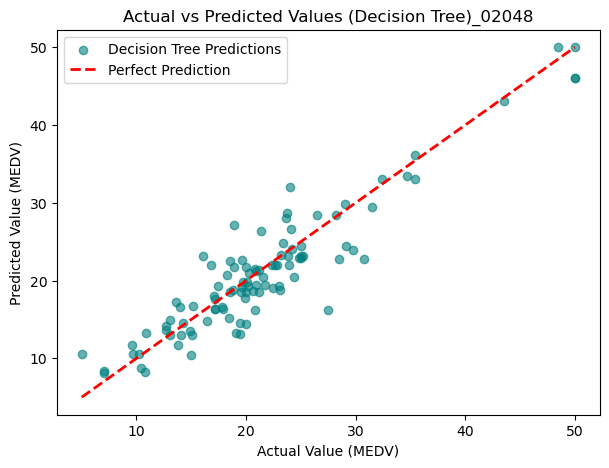

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, dt_predictions,
            color='teal',
            alpha=0.6,
            label='Decision Tree Predictions')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--',
         lw=2,
         label='Perfect Prediction')

plt.title("Actual vs Predicted Values (Decision Tree)_02048")
plt.xlabel("Actual Value (MEDV)")
plt.ylabel("Predicted Value (MEDV)")
plt.legend()

plt.show()

Task 3: Evaluate regression models using learning curves and appropriate error metrics
Continuous Evaluation and Diagnostic Metrics across All Models

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Performance metrics for Linear Regression
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_predictions)

# Performance metrics for Support Vector Regression
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)

# Performance metrics for Decision Tree Regression
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

# Create a comparison table
performance = pd.DataFrame({
    "Model": ["Linear Regression", "Support Vector Regression", "Decision Tree Regression"],
    "MAE": [lr_mae, svr_mae, dt_mae],
    "MSE": [lr_mse, svr_mse, dt_mse],
    "RMSE": [lr_rmse, svr_rmse, dt_rmse],
    "R² Score": [lr_r2, svr_r2, dt_r2]
})

print("Regression Model Performance Comparison")
print(performance)

Regression Model Performance Comparison
                       Model       MAE        MSE      RMSE  R² Score
0          Linear Regression  3.189092  24.291119  4.928602  0.668759
1  Support Vector Regression  2.731716  25.668540  5.066413  0.649977
2   Decision Tree Regression  2.394118  10.416078  3.227395  0.857963


Give Perform Regression Task on California Housing Dataset.

In [1]:
# Import Libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

# Load California Housing Dataset
housing = fetch_california_housing(as_frame=True)

# Features and Target
X = housing.data
y = housing.target

# Display first few rows
print(X.head())
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Linear Regression Model
model = LinearRegression()

# Train the Model
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\nR2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))

print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", mean_squared_error(y_test, y_pred) ** 0.5)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

R2 Score: 0.5757877060324511
Mean Absolute Error (MAE): 0.5332001304956566
Mean Squared Error (MSE): 0.555891598695244
Root Mean Squared Error (RMSE): 0.7455813830127761
